# Transformer-based Time Series Forecasting
This notebook replaces the LSTM model with a transformer encoder model for forecasting on a dataset containing multiple time series (identified by ID).

In [1]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout, LayerNormalization, GlobalAveragePooling1D, MultiHeadAttention
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback
from keras.optimizers import AdamW
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import shap

In [2]:
print(tf.__version__)


2.19.0


# INPUTS

In [3]:
dynamic_features = ['pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30']
static_features = ['mch_elevation', 'site_enc', 'species_enc', ' year_enc', 'day_cos', 'day_sin']  # static features
features = dynamic_features 
target_column = "twd_rolling30"

features_to_scale = [
    'pr_rolling30', 'at_rolling30', 'ws_rolling30',
    'dp_rolling30', 'sr_rolling30', 'lr_rolling30',
    'day_cos', 'day_sin',
    'mch_elevation', 
    'twd_rolling30'  # target
]

SEQ_LEN = 7 # number of past time steps the  model uses to make each prediction.
forec_horizon = 1  # number of future time steps to predict
my_patience = 30
my_epochs = 100
checkpoint_frequency = my_epochs //10 # Save a model checkpoint at every 10% of training
my_batch_size = 32
my_val_split = 0.2

np.random.seed(42)

## Load and preprocess data

In [4]:
df_ts_series = pd.read_csv('df.ts.series2.csv')
df_ts_series = df_ts_series[df_ts_series['species'] != 'Pseudotsuga menziesii']
#df_ts_series = df_ts_series[df_ts_series['at_rolling30'] >= 0]
df_ts_series 

,Unnamed: 0,site,tree.id,ts,twd,pr,at,ws,dp,sr,...,day.of.year_rolling30,site_longitude,site_latitude,site_easting,site_northing,mch_ind_closest,mch_easting,mch_northing,mch_elevation,mch_site_eucldist
0,1,Bachtel-Forest,1,2020-01-01,0.000000,-4.967054e-09,0.684757,1.197186,-3.640214,62.291590,...,NaN,8.89016,47.29413,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980
1,2,Bachtel-Forest,1,2020-01-02,0.121408,-1.092752e-07,0.213088,1.312338,-4.036302,60.923900,...,NaN,8.89016,47.29413,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980
2,3,Bachtel-Forest,1,2020-01-03,0.118271,1.285767e-01,2.009851,2.115951,-0.953911,55.859708,...,NaN,8.89016,47.29413,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980
3,4,Bachtel-Forest,1,2020-01-04,0.000000,9.927122e-02,1.573278,3.247398,0.721803,13.914832,...,NaN,8.89016,47.29413,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980
4,5,Bachtel-Forest,1,2020-01-05,0.000000,-1.986821e-08,-0.442240,2.159941,-4.094125,62.620516,...,NaN,8.89016,47.29413,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46027,46028,Sihlwald-Forest,42,2020-01-07,0.285428,2.295844e-02,1.842663,2.574209,-0.216778,37.274933,...,NaN,8.56111,47.25056,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303
46028,46029,Sihlwald-Forest,42,2020-01-08,0.258344,-6.457170e-07,3.056492,2.483577,-2.625516,47.995854,...,NaN,8.56111,47.25056,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303
46029,46030,Sihlwald-Forest,42,2020-01-09,0.509388,-1.182159e-06,4.842269,2.885992,-3.002886,54.513516,...,NaN,8.56111,47.25056,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303
46030,46031,Sihlwald-Forest,42,2020-01-10,0.603231,3.270944e-03,4.031820,3.103367,0.587544,39.948842,...,NaN,8.56111,47.25056,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303


For temperatures by species, see page 5/13 of roll_avg_analysis.pdf
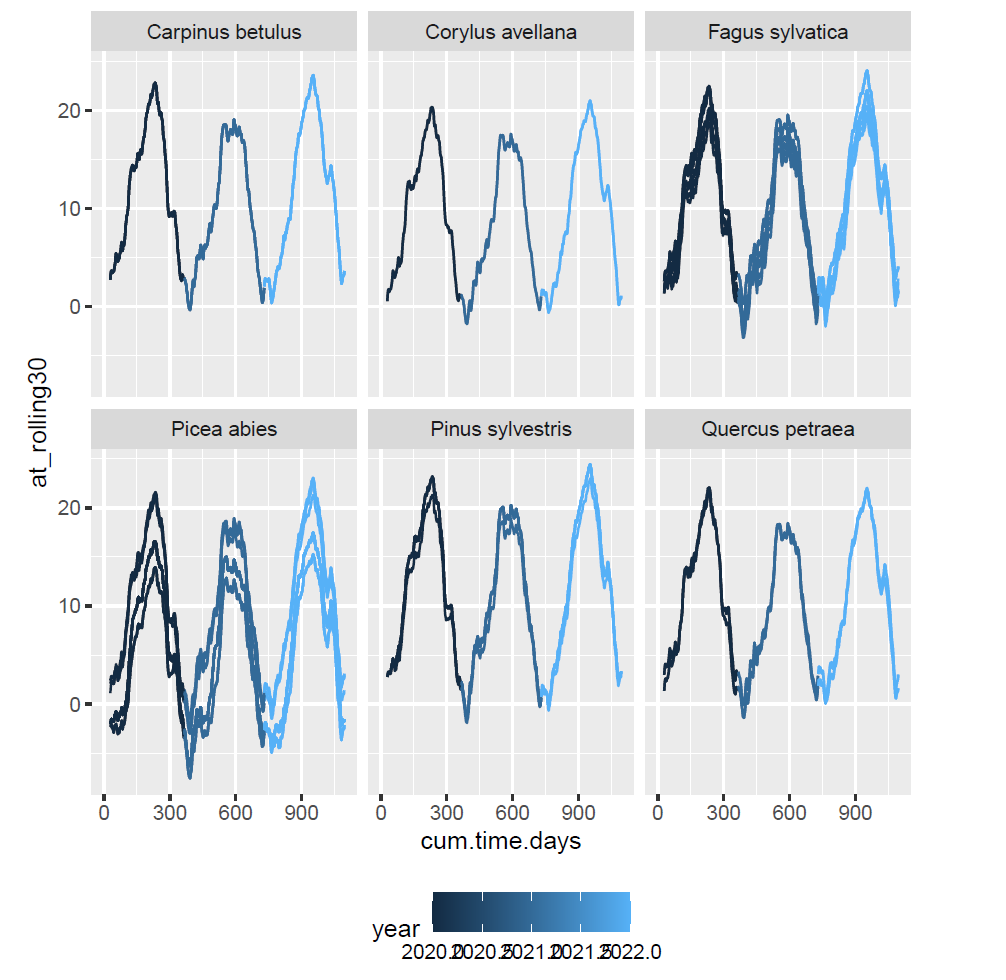

In [5]:
# Filter rows with temperature < 0°C
# should be 5C
below_5C = df_ts_series[df_ts_series['at_rolling30'] < 0]

# Group by site and species and count occurrences
low_temp_stats = below_5C.groupby(['site', 'species']).size().reset_index(name='count')

# Show which site-species combinations had temps < 5°C
print(low_temp_stats.sort_values(by='count', ascending=False))

                            site           species  count
16              Schmitten-Forest       Picea abies   2429
4              Davos-Seehornwald       Picea abies   1203
5          Hohtenn-Gampel-Forest       Picea abies    138
3            Choeliacher-Orchard  Corylus avellana     88
12  Pfynwald-Illgraben-Northwest       Picea abies     88
13           Pfynwald-Irrigation  Pinus sylvestris     84
0                 Bachtel-Forest   Fagus sylvatica     80
15                  Schaenis-low   Fagus sylvatica     79
17               Sihlwald-Forest   Fagus sylvatica     43
14                  Saillon-A860   Fagus sylvatica     40
7                    Lens-Forest  Pinus sylvestris     38
9            Neunkirch-Southeast   Quercus petraea     36
6                   Laegeren-Hut       Picea abies     36
8                Neunkirch-North   Fagus sylvatica     36
2                 Bursins-Forest  Carpinus betulus     32
11              Pfynwald-Control  Pinus sylvestris     28
10           N

In [6]:
type(df_ts_series)
print(df_ts_series.columns)
df_ts_series = df_ts_series.dropna(subset=['twd_rolling30'])
print(df_ts_series['twd_rolling30'])

Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day.of.year', 'month', 'week', 'twd_rolling7',
       'pr_rolling7', 'at_rolling7', 'ws_rolling7', 'dp_rolling7',
       'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7', 'twd_rolling30',
       'pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'site_longitude', 'site_latitude', 'site_easting', 'site_northing',
       'mch_ind_closest', 'mch_easting', 'mch_northing', 'mch_elevation',
       'mch_site_eucldist'],
      dtype='object')
29       0.565573
30       0.565573
31       0.561526
32       0.557584
33       0.557584
           ...   
46019    0.099176
46020    0.093326
46021    0.101662
46022    0.105229
46023    0.108795
Name: twd_rolling30, Length: 42680, dtype: float64


In [7]:
df_ts_series['site'] = df_ts_series['site'].astype(str)
df_ts_series['year'] = df_ts_series['year'].astype(str)
df_ts_series['species'] = df_ts_series['species'].astype(str)
df_ts_series['year'] = df_ts_series['year'].astype(str)

#encoders = {}
#for col in ['site', 'species', 'year']:
#    le = LabelEncoder()
#    df_ts_series[col + '_enc'] = le.fit_transform(df_ts_series[col])
#    encoders[col] = le

# Proper encoding for categorical features
le_site = LabelEncoder()
le_species = LabelEncoder()
le_year = LabelEncoder()

df_ts_series['site_enc'] = le_site.fit_transform(df_ts_series['site'])
df_ts_series['species_enc'] = le_species.fit_transform(df_ts_series['species'])
df_ts_series['year_enc'] = le_year.fit_transform(df_ts_series['year'])

C:\Users\salom\AppData\Local\Temp\ipykernel_15152\3444742641.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series['site'] = df_ts_series['site'].astype(str)
C:\Users\salom\AppData\Local\Temp\ipykernel_15152\3444742641.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series['year'] = df_ts_series['year'].astype(str)
C:\Users\salom\AppData\Local\Temp\ipykernel_15152\3444742641.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

In [8]:
df_ts_series

,Unnamed: 0,site,tree.id,ts,twd,pr,at,ws,dp,sr,...,site_easting,site_northing,mch_ind_closest,mch_easting,mch_northing,mch_elevation,mch_site_eucldist,site_enc,species_enc,year_enc
29,30,Bachtel-Forest,1,2020-01-30,0.000000,0.216286,1.671130,2.526737,-1.881127,92.544593,...,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980,0,2,0
30,31,Bachtel-Forest,1,2020-01-31,0.000000,0.106352,5.457554,2.084985,3.332546,27.745624,...,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980,0,2,0
31,32,Bachtel-Forest,1,2020-02-01,0.000000,0.214258,6.652724,3.561126,3.053819,54.054537,...,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980,0,2,0
32,33,Bachtel-Forest,1,2020-02-02,0.000000,0.538412,6.850142,4.429156,4.386041,8.521860,...,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980,0,2,0
33,34,Bachtel-Forest,1,2020-02-03,0.000000,0.714336,7.772078,5.932485,4.377917,2.515443,...,2.709787e+06,1.239153e+06,46975,2.710088e+06,1.239223e+06,882.140575,308.935980,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46019,46020,Sihlwald-Forest,42,2022-12-27,0.003764,0.078904,4.010645,1.909832,2.355262,26.803715,...,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303,18,2,2
46020,46021,Sihlwald-Forest,42,2022-12-28,0.000000,0.000003,3.266429,2.896402,-0.281365,48.663056,...,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303,18,2,2
46021,46022,Sihlwald-Forest,42,2022-12-29,0.250309,0.251616,6.377938,3.076757,1.008028,37.025694,...,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303,18,2,2
46022,46023,Sihlwald-Forest,42,2022-12-30,0.106996,0.461910,5.292577,2.608761,3.574435,32.584284,...,2.684971e+06,1.233901e+06,41819,2.684597e+06,1.233941e+06,722.265575,375.727303,18,2,2


You map each day to a point on a circle. This way:

- Day 1 and Day 366 end up very close on the circle

- The relationship between days is smooth and continuous

- Models (especially linear or neural nets) can better learn time patterns

C:\Users\salom\AppData\Local\Temp\ipykernel_15152\3176013121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series.rename(columns={'day.of.year': 'day_of_year'}, inplace=True)
C:\Users\salom\AppData\Local\Temp\ipykernel_15152\3176013121.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series['days_in_year'] = df_ts_series['year'].map(days_per_year)
C:\Users\salom\AppData\Local\Temp\ipykernel_15152\3176013121.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

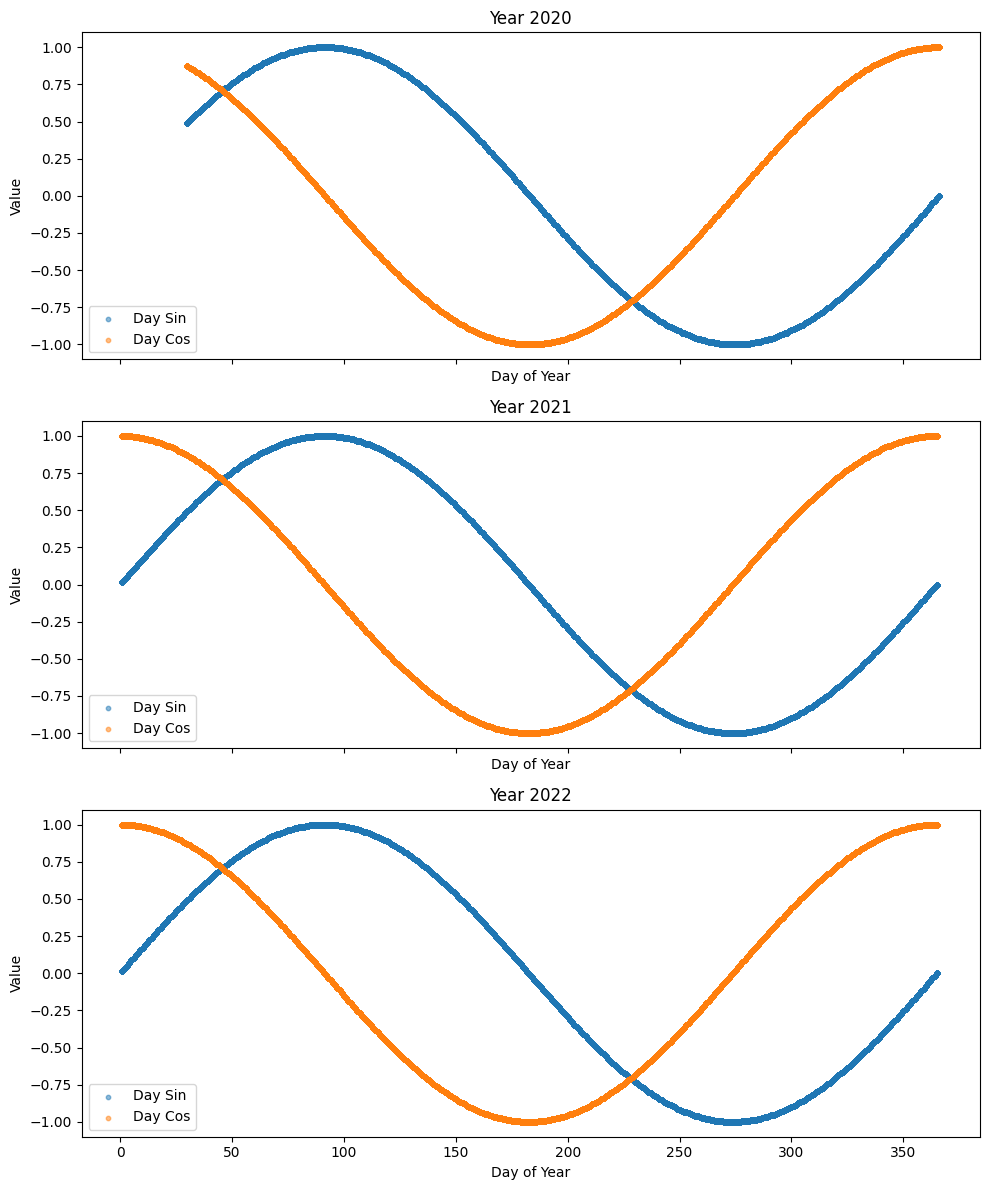

In [9]:
# change column name day.of.year to day_of_year, as numeric
df_ts_series.rename(columns={'day.of.year': 'day_of_year'}, inplace=True)


# Compute number of days per year (handles leap years)
days_per_year = df_ts_series.groupby('year')['day_of_year'].max().to_dict()

df_ts_series['days_in_year'] = df_ts_series['year'].map(days_per_year)
df_ts_series['day_sin'] = np.sin(2 * np.pi * df_ts_series['day_of_year'] / df_ts_series['days_in_year'])
df_ts_series['day_cos'] = np.cos(2 * np.pi * df_ts_series['day_of_year'] / df_ts_series['days_in_year'])

years = df_ts_series['year'].unique()
n_years = len(years)
nrows = 3  # Number of rows in the subplot grid
ncols = 1  # Number of columns in the subplot grid
# plot day_sin and day_cos as points (not lines)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4 * nrows), sharex=True, sharey=True)

for ax, year in zip(axes.flat, years):
    group = df_ts_series[df_ts_series['year'] == year]
    ax.scatter(group['day_of_year'], group['day_sin'], label='Day Sin', alpha=0.5, s=10)
    ax.scatter(group['day_of_year'], group['day_cos'], label='Day Cos', alpha=0.5, s=10)
    ax.set_title(f'Year {year}')
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Value')
    ax.legend()

# Hide any unused subplots
for i in range(n_years, nrows * ncols):
    fig.delaxes(axes.flat[i])

plt.tight_layout()
plt.show()

In [10]:
df_ts_series.groupby('year')['day_of_year'].min().to_dict()


{'2020': 30, '2021': 1, '2022': 1}

2020 starts at day 30 because of the rolling average. The first 30 days are not available in the dataset.

In [11]:
print(df_ts_series.columns)
df_ts_series["species_enc"]
# Assume you have these columns
print(df_ts_series['mch_elevation'])
print(df_ts_series['site'] )
print(df_ts_series['site_enc'] )


Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day_of_year', 'month', 'week', 'twd_rolling7',
       'pr_rolling7', 'at_rolling7', 'ws_rolling7', 'dp_rolling7',
       'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7', 'twd_rolling30',
       'pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'site_longitude', 'site_latitude', 'site_easting', 'site_northing',
       'mch_ind_closest', 'mch_easting', 'mch_northing', 'mch_elevation',
       'mch_site_eucldist', 'site_enc', 'species_enc', 'year_enc',
       'days_in_year', 'day_sin', 'day_cos'],
      dtype='object')
29       882.140575
30       882.140575
31       882.140575
32       882.140575
33       882.140575
            ...    
46019    722.265575
46020    722.265575
46021    722.265575
46022    722.265575
46023    722.26

In [12]:
# Initialize dictionary to store scalers
scalers = {}

# Scale each feature individually
for col in features_to_scale:
    scaler = MinMaxScaler()
    df_ts_series[col + '_scaled'] = scaler.fit_transform(df_ts_series[[col]])
    scalers[col] = scaler


C:\Users\salom\AppData\Local\Temp\ipykernel_15152\3433250838.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series[col + '_scaled'] = scaler.fit_transform(df_ts_series[[col]])
C:\Users\salom\AppData\Local\Temp\ipykernel_15152\3433250838.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts_series[col + '_scaled'] = scaler.fit_transform(df_ts_series[[col]])
C:\Users\salom\AppData\Local\Temp\ipykernel_15152\3433250838.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

## Create input sequences

In [13]:

# Create list of scaled dynamic features
dynamic_scaled_features = [f"{feat}_scaled" for feat in dynamic_features]

static_scaled_features = ['site_enc', 'species_enc', 'mch_elevation_scaled', 'year_enc', 'day_sin_scaled', 'day_cos_scaled' ]
target_scaled = target_column + '_scaled'
print(dynamic_scaled_features)
print(static_scaled_features)
print(target_scaled)


['pr_rolling30_scaled', 'at_rolling30_scaled', 'ws_rolling30_scaled', 'dp_rolling30_scaled', 'sr_rolling30_scaled', 'lr_rolling30_scaled']
['site_enc', 'species_enc', 'mch_elevation_scaled', 'year_enc', 'day_sin_scaled', 'day_cos_scaled']
twd_rolling30_scaled


In [14]:

def create_sequences(df, seq_len, forecast_horizon=1):
    X_seq, X_static, y, meta = [], [], [], []
    for series_id, group in df.groupby('tree.id'):
        if len(group) < seq_len + forecast_horizon:
            continue
        for i in range(len(group) - seq_len - forecast_horizon + 1):
            window = group.iloc[i:i+seq_len]
            target_window = group.iloc[i+seq_len:i+seq_len+forecast_horizon]
            
            X_seq.append(window[dynamic_scaled_features].values)
            static = group.iloc[i][static_scaled_features].values
            X_static.append(static)
            y.append(target_window[target_scaled].values)

        
            meta.append({
                'tree_id': series_id,
                'site': group.iloc[i]['site'],
                'species': group.iloc[i]['species'],
                'year': group.iloc[i]['year'], 
                'timestamps': window['cum.time.days'].tolist(),  # assuming your timestamp column is 'date',
                'day_sin': group.iloc[i]['day_sin'],
                'day_cos': group.iloc[i]['day_cos']
            })
    
    return np.array(X_seq), np.array(X_static), np.array(y), meta


Why the test set should be temporally after the training set
If your model sees future data during training, it will:
1. Leak information it wouldn’t have in reality.
2. Artificially inflate performance metrics.
3. Fail in production, where only past data is available to forecast the future.

In [15]:
# --- Split by time for each tree ---

# 1. For each tree, split by time (first 80% train, last 20% test)
train_indices, test_indices = [], []

for series_id, group in df_ts_series.groupby('tree.id'):
    # The split logic sorts by time
    group = group.sort_values('cum.time.days')
    n = len(group)
    split_point = int(n * 0.8)
    train_indices.extend(group.index[:split_point])
    test_indices.extend(group.index[split_point:])

df_train = df_ts_series.loc[train_indices].reset_index(drop=True)
df_test = df_ts_series.loc[test_indices].reset_index(drop=True)

# 2. Generate sequences separately for train and test sets
X_seq_train, X_static_train, y_train, meta_train = create_sequences(df= df_train, seq_len = SEQ_LEN, forecast_horizon = forec_horizon)
X_seq_test, X_static_test, y_test, meta_test = create_sequences(df= df_test, seq_len = SEQ_LEN, forecast_horizon = forec_horizon)

In [16]:
tree_info = meta_test[2] # example
print(tree_info)

{'tree_id': 1, 'site': 'Bachtel-Forest', 'species': 'Fagus sylvatica', 'year': '2022', 'timestamps': [884, 885, 886, 887, 888, 889, 890], 'day_sin': np.float64(0.4711595076738638), 'day_cos': np.float64(-0.8820480249558537)}


In [17]:

max_site_enc = int(df_ts_series['site_enc'].max())
print("Max site_enc:", max_site_enc)
max_species_enc = int(df_ts_series['species_enc'].max())
print("Max species_enc:", max_species_enc)
max_year_enc = int(df_ts_series['year_enc'].max())
print("Max year_enc:", max_year_enc)

Max site_enc: 18
Max species_enc: 5
Max year_enc: 2


## Define transformer block

R² is not differentiable in a stable way, Use R² only as a monitoring metric during training. R2 pertains to the whole batch, 

If your model predicts forecast_horizon = 7 future steps (i.e., y_pred.shape = (batch_size, 7)), you can compute R² per output like this:

In [18]:
def transformer_block(x, head_size, num_heads, ff_dim, dropout=0.1):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = LayerNormalization(epsilon=1e-6)(x + attn_output)
    ff_output = Dense(ff_dim, activation="relu")(x)
    ff_output = Dense(x.shape[-1])(ff_output)
    return LayerNormalization(epsilon=1e-6)(x + ff_output)


In [19]:
def r2_score_per_timestep(y_true, y_pred):
    # Compute R² for each time step separately and return the average
    
    diff = y_true - y_pred
    #tf.print("Shape of y_true:", tf.shape(y_true)) # [31 1]
    # tf.print("Shape of y_pred:", tf.shape(y_pred))  # [31 1]
    
    ss_res = K.sum(K.square(diff), axis=0)
    ss_tot = K.sum(K.square(y_true - K.mean(y_true, axis=0)), axis=0)
    r2 = 1 - (ss_res / (ss_tot + K.epsilon()))
    return K.mean(r2)

## Build and compile the transformer model

In [20]:
n_features = X_seq_test.shape[-1]
print(n_features)

# Inputs
seq_input = Input(shape=(SEQ_LEN, n_features), name='seq_input')
site_input = Input(shape=(1,), name='site')
species_input = Input(shape=(1,), name='species')
mch_input = Input(shape=(1,), name='mch_input')
year_input = Input(shape=(1,), name='year_input')
day_sin_input = Input(shape=(1,), name='day_sin')
day_cos_input = Input(shape=(1,), name='day_cos')

# Static embeddings
# Always set input_dim = max value in column + 1.
site_emb = Embedding(input_dim= 19, output_dim=2)(site_input)
species_emb = Embedding(input_dim= 6, output_dim=4)(species_input)
site_vec = Flatten()(site_emb)
species_vec = Flatten()(species_emb)

# Positional encoding
positions = tf.range(start=0, limit=SEQ_LEN, delta=1)
pos_embedding = Embedding(input_dim=SEQ_LEN, output_dim=n_features)(positions)
pos_encoded = seq_input + pos_embedding

# Transformer block
# temporal feature learning capacity
# More transformer blocks stacked enhances temporal pattern learning.
x = transformer_block(pos_encoded, head_size=32, num_heads=4, ff_dim=128)
x = Dropout(0.2)(x)
x = transformer_block(x, head_size=32, num_heads=4, ff_dim=128)
x = Dropout(0.2)(x)
x = GlobalAveragePooling1D()(x)

# Combine with static
static_vec = Concatenate()([site_vec, species_vec, mch_input, year_input, day_sin_input, day_cos_input])
combined = Concatenate()([x, static_vec])

# Output, use RELU or softplus to avoid negative values
# forecast of the next time step (1-step-ahead).
output = Dense(forec_horizon, activation='softplus')(combined)

# weight_decay=0 disables the benefits of AdamW
optimizer = AdamW(learning_rate=1e-5, weight_decay=1e-4)
model = Model(inputs=[seq_input, mch_input, site_input, species_input, year_input, day_sin_input, day_cos_input], outputs=output)
model.compile(
    optimizer=optimizer,
    # Still use MSE or MAE for training
    loss='mse',
    metrics=[r2_score_per_timestep]
    )  # You may consider 'mae' for multi-step
model.summary()


6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 7, 6)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 7, 6)      │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 6)      │      3,462 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 7, 6)      │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 7, 6)      │         12 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 7, 128)    │        896 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7, 6)      │        774 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 7, 6)      │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 6)      │         12 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 7, 6)      │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 6)      │      3,462 │ dropout_1[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 7, 6)      │          0 │ dropout_1[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 6)      │         12 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7, 128)    │        896 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 7, 6)      │        774 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 7, 6)      │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ site (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 6)      │         12 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 10,391 (40.59 KB)

 Trainable params: 10,391 (40.59 KB)

 Non-trainable params: 0 (0.00 B)

## Train the model

In [21]:
X_static_train

array([[np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7462763145605751),
        np.float64(0.9351426205150777)],
       [np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7537098960674915),
        np.float64(0.930850879974034)],
       [np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7610687081035219),
        np.float64(0.9264321657010799)],
       ...,
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.8210303294438235),
        np.float64(0.1166705903499205)],
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.8143843185796449),
        np.float64(0.11120142651318654)],
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.8076451488569021),
        np.float64(0.10584747208473727)]], dtype=object)

In [22]:
features_to_scale

['pr_rolling30',
 'at_rolling30',
 'ws_rolling30',
 'dp_rolling30',
 'sr_rolling30',
 'lr_rolling30',
 'day_cos',
 'day_sin',
 'mch_elevation',
 'twd_rolling30']

In [23]:
class PeriodicCheckpoint(Callback):
    def __init__(self, save_path, frequency):
        super().__init__()
        self.save_path = save_path
        self.frequency = frequency

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.frequency == 0:
            filepath = os.path.join(self.save_path, f"model_epoch_{epoch+1}.h5")
            self.model.save(filepath)
            print(f"✅ Saved model at epoch {epoch + 1} to {filepath}")

     

In [24]:
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_callback = PeriodicCheckpoint(save_path=checkpoint_dir, frequency=checkpoint_frequency)       

In [25]:
early_stopping = EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience= my_patience,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

In [26]:
X_static_train

array([[np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7462763145605751),
        np.float64(0.9351426205150777)],
       [np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7537098960674915),
        np.float64(0.930850879974034)],
       [np.int64(0), np.int64(2), np.float64(0.30634938285332924),
        np.int64(0), np.float64(0.7610687081035219),
        np.float64(0.9264321657010799)],
       ...,
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.8210303294438235),
        np.float64(0.1166705903499205)],
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.8143843185796449),
        np.float64(0.11120142651318654)],
       [np.int64(18), np.int64(2), np.float64(0.1641276548426548),
        np.int64(2), np.float64(0.8076451488569021),
        np.float64(0.10584747208473727)]], dtype=object)

In [27]:
fit_model = True  # Set to False to load the model instead of fitting

if not fit_model and os.path.exists("transformer_model.h5"):
    model = tf.keras.models.load_model("transformer_model.h5", custom_objects={"r2_score_per_timestep": r2_score_per_timestep})
    history = None
else:
    # Model will be fit below
    history = model.fit(
        {
            'seq_input': X_seq_train,
            'mch_input': X_static_train[:, 2].astype(np.float32),
            'site': X_static_train[:, 0].astype(np.int32),
            'species': X_static_train[:, 1].astype(np.int32),
            'year_input': X_static_train[:, 3].astype(np.int32),
            'day_sin': X_static_train[:, 4].astype(np.float32),
            'day_cos': X_static_train[:, 5].astype(np.float32),
        },
        y_train,
        validation_split= my_val_split,
        epochs=my_epochs,
        batch_size= my_batch_size,
        callbacks=[early_stopping, checkpoint_callback]
    )
    # Save the model after training
    model.save("transformer_model.h5")


Epoch 1/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 1.2282 - r2_score_per_timestep: -85.3116 - val_loss: 0.0285 - val_r2_score_per_timestep: -308195.4062
Epoch 2/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - loss: 0.1113 - r2_score_per_timestep: -6.9736 - val_loss: 0.0126 - val_r2_score_per_timestep: -96132.1016
Epoch 3/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 38s 42ms/step - loss: 0.0370 - r2_score_per_timestep: -1.4423 - val_loss: 0.0124 - val_r2_score_per_timestep: -66241.1953
Epoch 4/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - loss: 0.0269 - r2_score_per_timestep: -0.7155 - val_loss: 0.0126 - val_r2_score_per_timestep: -56489.4609
Epoch 5/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - loss: 0.0245 - r2_score_per_timestep: -0.5619 - val_loss: 0.0128 - val_r2_score_per_timestep: -51459.0742
Epoch 6/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - loss: 0.0228 - r2_score_per_timestep: -0.4326 - val_loss: 0.0130 - val_r2_score_per_timestep: -48073.2734
Epoch 7/100
846/846 ━

✅ Saved model at epoch 10 to checkpoints\model_epoch_10.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0208 - r2_score_per_timestep: -0.2174 - val_loss: 0.0136 - val_r2_score_per_timestep: -36915.2031
Epoch 11/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0201 - r2_score_per_timestep: -0.1897 - val_loss: 0.0137 - val_r2_score_per_timestep: -34737.8242
Epoch 12/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0196 - r2_score_per_timestep: -0.1645 - val_loss: 0.0136 - val_r2_score_per_timestep: -32978.6406
Epoch 13/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0190 - r2_score_per_timestep: -0.1433 - val_loss: 0.0133 - val_r2_score_per_timestep: -31762.9277
Epoch 14/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0189 - r2_score_per_timestep: -0.1341 - val_loss: 0.0126 - val_r2_score_per_timestep: -30759.0137
Epoch 15/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0180 - r2_score_per_timestep: -0.0734 - val_loss: 0.0121 - val_r2_score_per_tim

✅ Saved model at epoch 20 to checkpoints\model_epoch_20.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0158 - r2_score_per_timestep: 0.0580 - val_loss: 0.0192 - val_r2_score_per_timestep: -22338.1406
Epoch 21/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0153 - r2_score_per_timestep: 0.0674 - val_loss: 0.0207 - val_r2_score_per_timestep: -21689.8906
Epoch 22/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0151 - r2_score_per_timestep: 0.0523 - val_loss: 0.0211 - val_r2_score_per_timestep: -21435.2969
Epoch 23/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0146 - r2_score_per_timestep: 0.0882 - val_loss: 0.0226 - val_r2_score_per_timestep: -21247.7598
Epoch 24/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0148 - r2_score_per_timestep: 0.1057 - val_loss: 0.0218 - val_r2_score_per_timestep: -20661.5410
Epoch 25/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0145 - r2_score_per_timestep: 0.1038 - val_loss: 0.0215 - val_r2_score_per_timestep: 

✅ Saved model at epoch 30 to checkpoints\model_epoch_30.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0140 - r2_score_per_timestep: 0.1335 - val_loss: 0.0230 - val_r2_score_per_timestep: -19363.8691
Epoch 31/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0139 - r2_score_per_timestep: 0.1621 - val_loss: 0.0227 - val_r2_score_per_timestep: -18785.5723
Epoch 32/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 0.0139 - r2_score_per_timestep: 0.1719 - val_loss: 0.0241 - val_r2_score_per_timestep: -19282.8535
Epoch 33/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0138 - r2_score_per_timestep: 0.1698 - val_loss: 0.0241 - val_r2_score_per_timestep: -19436.0977
Epoch 34/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0134 - r2_score_per_timestep: 0.1838 - val_loss: 0.0246 - val_r2_score_per_timestep: -19447.5488
Epoch 35/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0133 - r2_score_per_timestep: 0.1953 - val_loss: 0.0228 - val_r2_score_per_t

✅ Saved model at epoch 40 to checkpoints\model_epoch_40.h5
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0128 - r2_score_per_timestep: 0.2125 - val_loss: 0.0232 - val_r2_score_per_timestep: -19361.9355
Epoch 41/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0130 - r2_score_per_timestep: 0.2118 - val_loss: 0.0212 - val_r2_score_per_timestep: -18840.4199
Epoch 42/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0127 - r2_score_per_timestep: 0.2232 - val_loss: 0.0214 - val_r2_score_per_timestep: -18874.3770
Epoch 43/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0129 - r2_score_per_timestep: 0.2248 - val_loss: 0.0231 - val_r2_score_per_timestep: -18578.2891
Epoch 44/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0125 - r2_score_per_timestep: 0.2274 - val_loss: 0.0234 - val_r2_score_per_timestep: -18860.8926
Epoch 45/100
846/846 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0125 - r2_score_per_timestep: 0.2400 - val_loss: 0.0226 - val_r2_score_per_timeste

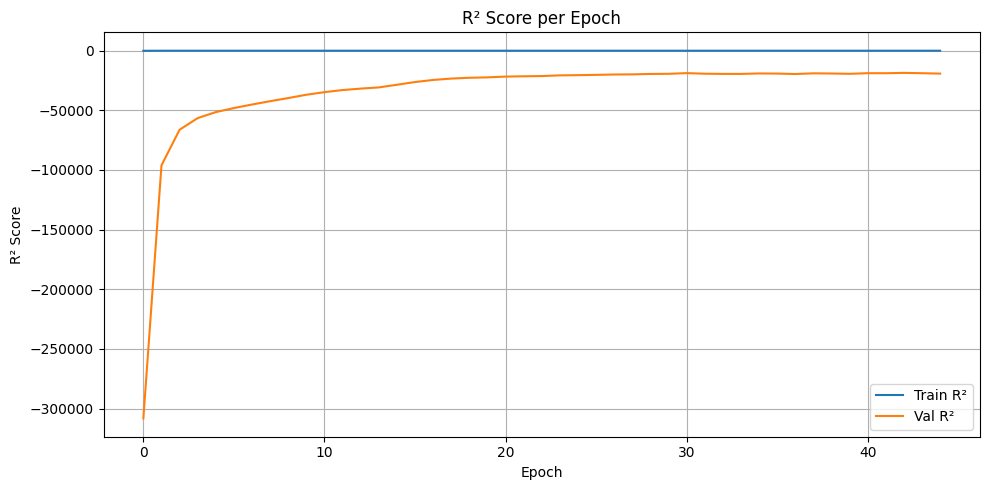

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['r2_score_per_timestep'], label='Train R²')
plt.plot(history.history['val_r2_score_per_timestep'], label='Val R²')
plt.title("R² Score per Epoch")
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

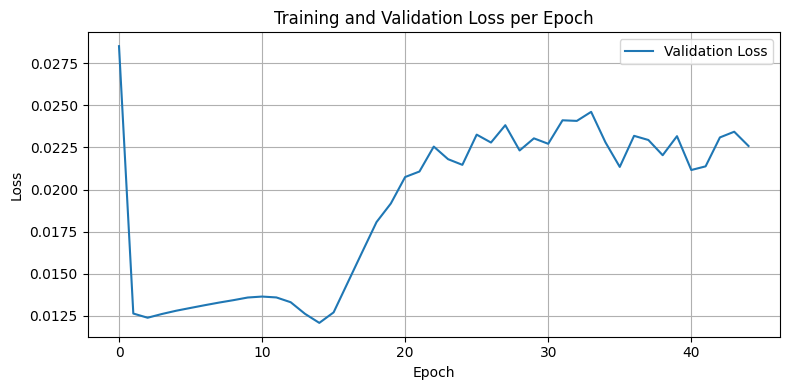

In [31]:
plt.figure(figsize=(8, 4))
#plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Evaluate the model

In [ ]:
loss = model.evaluate(
    {
        'seq_input': X_seq_test,
        'mch_input': X_static_test[:, 2].astype(np.float32),
        'site': X_static_test[:, 0].astype(np.int32),
        'species': X_static_test[:, 1].astype(np.int32),
        'year_input': X_static_test[:, 3].astype(np.int32),
        'day_sin': X_static_test[:, 4].astype(np.float32),
        'day_cos': X_static_test[:, 5].astype(np.float32)
    },
    y_test
)
print("Test Loss:", loss)


In [ ]:
# Flatten the sequence input
sample_size = 20  # can adjust this
# Flatten seq_input (shape: n, seq_len, n_features) → (n, seq_len * n_features)
seq_flat = X_seq_test.reshape((X_seq_test.shape[0], -1))

# Concatenate with static features (site, species, mch)
X_shap = np.concatenate([seq_flat, X_static_test], axis=1).astype(np.float32)


In [ ]:
def model_predict(data):
    n_seq_features = X_seq_test.shape[2]
    seq_len = X_seq_test.shape[1]
    
    seq_input = data[:, :seq_len * n_seq_features].reshape((-1, seq_len, n_seq_features))
    site_input = data[:, seq_len * n_seq_features].astype(np.int32).reshape(-1, 1)
    species_input = data[:, seq_len * n_seq_features + 1].astype(np.int32).reshape(-1, 1)
    mch_input = data[:, seq_len * n_seq_features + 2].astype(np.float32).reshape(-1, 1)
    year_input = data[:, seq_len * n_seq_features + 3].astype(np.int32).reshape(-1, 1)
    day_sin_input = data[:, seq_len * n_seq_features + 4].astype(np.float32).reshape(-1, 1)
    day_cos_input = data[:, seq_len * n_seq_features + 5].astype(np.float32).reshape(-1, 1)
    
    # Return only the prediction for day 3, for example
    return model.predict({
        'seq_input': seq_input,
        'mch_input': mch_input,
        'site': site_input,
        'species': species_input,
        'year_input': year_input,
        'day_sin': day_sin_input,
        'day_cos': day_cos_input
    })[:, 0]  # Only the 1st day



In [ ]:
print(X_shap.shape)
print(SEQ_LEN == X_seq_test.shape[1])
n_dyn = X_seq_test.shape[2]

dynamic_names = [f"{feat}_t{t}" for t in range(SEQ_LEN) for feat in dynamic_scaled_features]
static_names = ['site_enc', 'species_enc', 'mch_scaled', 'year_enc', 'day_sin_scaled', 'day_cos_scaled']
feature_names = dynamic_names + static_names
print(feature_names)

 background = X_shap[:20]: A sample of representative input data used by SHAP to estimate the baseline prediction (i.e., what the model would predict in the absence of specific feature values. You're telling SHAP to use the first 20 samples from your input data as the background set for reference.

In [ ]:
# background = X_shap[:20]
background = X_shap[np.random.choice(len(X_shap), 100, replace=False)]
explainer = shap.KernelExplainer(model_predict, background)
#shap_values = explainer.shap_values(X_shap[:5])

In [ ]:
# === Compute SHAP values ===
# If your model outputs 7 values (7-day forecast), specify ranked_outputs=1 to pick the most important one
# Make sure your input is shaped (samples, features), not (features, samples)
nb_samples_shap = 40

# Randomly select nb_samples_shap indices
indices = np.random.choice(len(X_shap), nb_samples_shap, replace=False)
X_shap_subset = X_shap[indices]

shap_values = explainer.shap_values(X_shap_subset) # shape: (5, 183)
print(shap_values.shape)

In [ ]:
shap.summary_plot(shap_values, X_shap_subset, feature_names=feature_names)

In [ ]:
# Plot the distribution of each input variable (scaled dynamic and static features)

input_vars = dynamic_scaled_features + static_scaled_features
plt.figure(figsize=(16, 10))
for i, col in enumerate(input_vars):
    plt.subplot(3, int(np.ceil(len(input_vars)/3)), i+1)
    sns.histplot(df_ts_series[col], kde=True, bins=30)
    plt.title(col)
    plt.tight_layout()
plt.show()

In [ ]:
site_enc_idx = feature_names.index('site_enc')

# Print unique values of site_enc in X_shap_subset
print("Unique site_enc in X_shap_subset:", np.unique(X_shap_subset[:, site_enc_idx]))

# To get the corresponding site names, map site_enc back to site using the label encoder
unique_site_encs = np.unique(X_shap_subset[:, site_enc_idx]).astype(int)
unique_sites = le_site.inverse_transform(unique_site_encs)
print("Corresponding site names:", unique_sites)

# Assume shap_values shape: (nb_samples_shap, n_features)
# Find the index of 'site_enc' in your feature_names
site_idx = feature_names.index('site_enc')

# Get the site_enc values for your SHAP sample
site_enc_values = X_shap_subset[:, site_idx]
print("Site Enc Values:", site_enc_values)
site_shap = shap_values[:, site_idx]

# Create a DataFrame for easy grouping
df_site = pd.DataFrame({
    'site_enc': site_enc_values,
    'shap': site_shap
})

# Calculate mean absolute SHAP value per site
site_shap_mean = df_site.groupby('site_enc')['shap'].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False)

plt.figure(figsize=(10,5))
site_shap_mean.plot(kind='bar')
plt.title('Mean |SHAP value| per site_enc')
plt.xlabel('site_enc')
plt.ylabel('Mean |SHAP value|')
plt.show()

In [ ]:
print("Unique site_enc in X_static_test:", np.unique(X_static_test[:, 0]))
print("Unique site_enc in X_shap:", np.unique(X_shap[:, site_idx]))

In [ ]:
site_enc_values = X_shap[:nb_samples_shap, site_idx]
site_enc_values

In [ ]:
print("First few target values:", y_train[:10, 0])
print(np.mean(y_train[:, 0]), np.std(y_train[:, 0]))

In [ ]:
y_pred = model.predict({
    'seq_input': X_seq_test.astype(np.float32),
    'mch_input': X_static_test[:, 2].astype(np.float32).reshape(-1, 1),
    'site': X_static_test[:, 0].astype(np.int32).reshape(-1, 1),
    'species': X_static_test[:, 1].astype(np.int32).reshape(-1, 1),
    'year_input': X_static_test[:, 3].astype(np.int32).reshape(-1, 1),
    'day_sin': X_static_test[:, 4].astype(np.float32).reshape(-1, 1),
    'day_cos': X_static_test[:, 5].astype(np.float32).reshape(-1, 1)
})


In [ ]:
print("y_pred shape:", y_pred.shape) # Number of sequences
print("Total predicted values:", y_pred.shape[0] * y_pred.shape[1])

In [ ]:
# Plot true vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test[:, 0], label='True', alpha=0.7)
plt.plot(y_pred[:, 0], label='Predicted', alpha=0.7)
plt.title('True vs Predicted Values on Test Set')
plt.xlabel('Sample Index')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import seaborn as sns

# Add day_of_year to plot_df
plot_df = pd.DataFrame({
    'True': y_test[:, 0],
    'Predicted': y_pred[:, 0],
    'Species': species_list,
    'Index': np.arange(len(y_test)),
    'day_of_year': df_test['day_of_year'].iloc[SEQ_LEN:SEQ_LEN+len(y_test)].values  # adjust if needed
})

# Melt for long-form plotting
plot_df_long = plot_df.melt(
    id_vars=['Index', 'Species', 'day_of_year'],
    value_vars=['True', 'Predicted'],
    var_name='Type',
    value_name='Value'
)

# FacetGrid by species, color by day_of_year, shape by Type
g = sns.FacetGrid(
    plot_df_long,
    col="Species",
    col_wrap=1,
    height=8,
    sharey=False,
    sharex=False  # Free x-axis
)
g.map_dataframe(
    sns.scatterplot,
    x="Index",
    y="Value",
    hue="day_of_year",
    style="Type",
    palette="viridis",
    alpha=0.8
)
g.add_legend()
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Sample Index", "Scaled Value")
plt.tight_layout()
plt.show()

In [ ]:
y_test.shape

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(forec_horizon):
    plt.plot(y_test[:, i], label=f'True t+{i+1}', alpha=0.5)
    plt.plot(y_pred[:, i], label=f'Predicted t+{i+1}', alpha=0.5, linestyle='--')
plt.title('Multi-step Prediction')
plt.xlabel('Sample Index')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_pred

In [ ]:
# Pick 5 random indices from the test set

random_indices = np.random.choice(len(X_seq_test), size=5, replace=False)

for idx in random_indices:
    tree_info = meta_test[idx]
    tree_id = tree_info['tree_id']
    timestamps = tree_info['timestamps']
    last_time = timestamps[-1]
    future_dates = [last_time + i for i in range(1, forec_horizon + 1)]

    # Get the true input sequence from the DataFrame
    mask = (df_ts_series['tree.id'] == tree_id) & (df_ts_series['cum.time.days'].isin(timestamps))
    input_seq_true = df_ts_series.loc[mask, 'twd_rolling30'].values
    input_seq_scaled = df_ts_series.loc[mask, 'twd_rolling30_scaled'].values

    true = y_test[idx]
    pred = model.predict({
        'seq_input': X_seq_test[idx:idx+1],
        'mch_input': X_static_test[idx:idx+1, 2].reshape(-1, 1).astype(np.float32),
        'site': X_static_test[idx:idx+1, 0].reshape(-1, 1).astype(np.int32),
        'species': X_static_test[idx:idx+1, 1].reshape(-1, 1).astype(np.int32),
        'year_input': X_static_test[idx:idx+1, 3].reshape(-1, 1).astype(np.int32),
        'day_sin': X_static_test[idx:idx+1, 4].reshape(-1, 1).astype(np.float32),
        'day_cos': X_static_test[idx:idx+1, 5].reshape(-1, 1).astype(np.float32)
    })[0]

    scaler = scalers['twd_rolling30']
    true_unscaled = scaler.inverse_transform(true.reshape(-1, 1)).flatten()
    pred_unscaled = scaler.inverse_transform(pred.reshape(-1, 1)).flatten()
    input_unscaled = input_seq_true  # Already in original units

    # --- Plot 1: Unscaled (original units) ---
    plt.figure(figsize=(10, 4))
    plt.plot(timestamps, input_unscaled, label="Input", marker='o')
    plt.plot(future_dates, true_unscaled, label="True Future", marker='o', color='green')
    plt.plot(future_dates, pred_unscaled, label="Predicted Future", marker='o', color='orange')
    plt.axvline(x=last_time, linestyle='--', color='gray', label='Forecast Start')
    plt.title(f"Tree ID: {tree_info['tree_id']}, Site: {tree_info['site']}, Species: {tree_info['species']}\nOriginal Units")
    plt.xlabel("Time (Numeric)")
    plt.ylabel("Tree Water Deficit")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    # --- Plot 2: Scaled values ---
    plt.figure(figsize=(10, 4))
    plt.plot(timestamps, input_seq_scaled, label="Input (scaled)", marker='o')
    plt.plot(future_dates, true, label="True Future (scaled)", marker='o', color='green')
    plt.plot(future_dates, pred, label="Predicted Future (scaled)", marker='o', color='orange')
    plt.axvline(x=last_time, linestyle='--', color='gray', label='Forecast Start')
    plt.title(f"Tree ID: {tree_info['tree_id']}, Site: {tree_info['site']}, Species: {tree_info['species']}\nScaled Values")
    plt.xlabel("Time (Numeric)")
    plt.ylabel("Tree Water Deficit (scaled)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [ ]:
print(future_dates)
print(pred_unscaled)

In [ ]:
print(X_seq_test.shape)
a = X_seq[test_idx]
print(df_ts_series.columns)
#print(df_ts_series['tree.id'])
filtered = df_ts_series[df_ts_series['tree.id'] == 8]
cols = ['site', 'species','cum.time.days', 'twd_rolling30']
filtered2 = filtered[cols]
print(filtered2[(filtered2['cum.time.days'] > 460) & (filtered2['cum.time.days'] < 472)])

meta_test
['pr_rolling30_scaled', 'at_rolling30_scaled', 'ws_rolling30_scaled', 'dp_rolling30_scaled', 'sr_rolling30_scaled', 'lr_rolling30_scaled']
['site_enc', 'species_enc', 'mch_elevation_scaled']
